
## Deriving SVG transitions by diffing formal states

`anim_algebra.py` is an AST representing SVG animations, by diffing two fully
rendered SVG frames so that a transition is provably exactly the attribute
delta between two formal states.

Idea:

```python
svg_generator(state, recipe, base_svg)   # state -> one concrete svg frame
svg_diff(svg_a, svg_b)                   # two frames -> an Animation
animate_trace(states, recipe, base_svg)  # a whole scenario -> one Animation
```

`Animation`s combine with `+` (associative, not commutative,
identity `E`) and `|` (parallel merge of svg ids that don't overlap;
raises `AnimationConflict` otherwise). Both operators always normalize
their result, which is what makes `(a+b)+c == a+(b+c)` and
`(a1|a2)+b == (a1+b)|(a2+b)` hold by construction rather than by
simulating them and checking. See Part 1 below.


In [1]:
import sys, os
import xml.etree.ElementTree as ET
import IPython.display
from anim_algebra import (
    Op, Leaf, Seq, Par, E, AnimationConflict,
    svg_generator, svg_diff, animate_trace, compile_to_svg, assert_laws,
)

def leaf(*ids, attr="fill", old="red", new="blue"):
    return Leaf(frozenset(Op("snap", i, attr, old, new) for i in ids))


### Part 1: the algebra

In [9]:
a, b, c = leaf("door"), leaf("cabin"), leaf("lamp")

print("(a + b) + c == a + (b + c):  ", (a + b) + c == a + (b + c))
print("a + b == b + a:              ", a + b == b + a, " (expected False: + is not commutative)")
print("a + E == a == E + a:         ", a + E == a == E + a)
print(E, a + E, a + a)

a1, a2, bb = leaf("x1"), leaf("x2"), leaf("y")
lhs = (a1 | a2) + bb
rhs = (a1 + bb) | (a2 + bb)
print("(a1|a2)+b == (a1+b)|(a2+b):  ", lhs == rhs)
print("  both sides normalize to:  ", lhs)

try:
    leaf("x", new="blue") | leaf("x", new="green")
except AnimationConflict as e:
    print("\nconflicting parallel branches correctly rejected:")
    print(" ", e)

assert_laws()


(a + b) + c == a + (b + c):   True
a + b == b + a:               False  (expected False: + is not commutative)
a + E == a == E + a:          True
Seq(children=()) Leaf(ops=frozenset({Op(kind='snap', id='door', attr='fill', old='red', new='blue', parent_id=None, elem_xml=None)})) Seq(children=(Leaf(ops=frozenset({Op(kind='snap', id='door', attr='fill', old='red', new='blue', parent_id=None, elem_xml=None)})), Leaf(ops=frozenset({Op(kind='snap', id='door', attr='fill', old='red', new='blue', parent_id=None, elem_xml=None)}))))
(a1|a2)+b == (a1+b)|(a2+b):   True
  both sides normalize to:   Seq(children=(Par(branches=(Leaf(ops=frozenset({Op(kind='snap', id='x1', attr='fill', old='red', new='blue', parent_id=None, elem_xml=None)})), Leaf(ops=frozenset({Op(kind='snap', id='x2', attr='fill', old='red', new='blue', parent_id=None, elem_xml=None)})))), Leaf(ops=frozenset({Op(kind='snap', id='y', attr='fill', old='red', new='blue', parent_id=None, elem_xml=None)}))))

conflicting parallel branc


### Part 2: `svg_diff`

Tests redone.

case 1 OK -- 5 ops: [('add', 'new'), ('add', '~anon0'), ('remove', 'gone'), ('tween', 'c1'), ('tween', 'c1')]


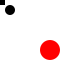

In [3]:
# 1: basic recolor + move + add + remove
svg_a = '''<svg xmlns="http://www.w3.org/2000/svg">
  <circle cx="10" cy="10" r="5"/>
  <circle id="c1" cx="50" cy="50" r="10" fill="red"/>
  <rect id="gone" x="0" y="0" width="5" height="5"/>
</svg>'''
svg_b = '''<svg xmlns="http://www.w3.org/2000/svg">
  <rect x="0" y="0" width="20" height="20"/>
  <circle id="c1" cx="100" cy="50" r="10" fill="blue"/>
  <rect id="new" x="1" y="1" width="2" height="2"/>
</svg>'''
d1 = svg_diff(svg_a, svg_b)
assert Op("tween", "c1", "cx", "50", "100") in d1.ops
assert Op("tween", "c1", "fill", "red", "blue") in d1.ops
assert Op("remove", "gone") in d1.ops
assert any(op.kind == "add" and op.id == "new" for op in d1.ops)
print("case 1 OK --", len(d1.ops), "ops:", sorted((op.kind, op.id) for op in d1.ops))
IPython.display.SVG(compile_to_svg(d1, svg_a))


In [4]:
# 2: nested new subtree must NOT be double-inserted
svg_a2 = '<svg xmlns="http://www.w3.org/2000/svg"></svg>'
svg_b2 = '''<svg xmlns="http://www.w3.org/2000/svg">
  <g id="grp"><circle id="inner" cx="1" cy="1" r="1"/></g>
</svg>'''
d2 = svg_diff(svg_a2, svg_b2)
adds = [op for op in d2.ops if op.kind == "add"]
assert len(adds) == 1 and adds[0].id == "grp" and "inner" in adds[0].elem_xml
print("case 2 OK, exactly one add op, nested id carried along:", adds[0].id)

# 3: reparent, same id, same tag, different parent group
svg_a3 = '''<svg xmlns="http://www.w3.org/2000/svg">
  <g id="g1"><circle id="c" cx="1" cy="1" r="1"/></g><g id="g2"></g>
</svg>'''
svg_b3 = '''<svg xmlns="http://www.w3.org/2000/svg">
  <g id="g1"></g><g id="g2"><circle id="c" cx="1" cy="1" r="1"/></g>
</svg>'''
d3 = svg_diff(svg_a3, svg_b3)
assert any(op.kind == "reparent" and op.id == "c" and op.parent_id == "g2" for op in d3.ops)
print("case 3 OK, reparent detected:", [op for op in d3.ops if op.kind == "reparent"][0])

# 4: tag change, same id
svg_a4 = '<svg xmlns="http://www.w3.org/2000/svg"><circle id="x" cx="1" cy="1" r="1"/></svg>'
svg_b4 = '<svg xmlns="http://www.w3.org/2000/svg"><rect id="x" x="1" y="1" width="2" height="2"/></svg>'
d4 = svg_diff(svg_a4, svg_b4)
assert Op("remove", "x") in d4.ops and any(op.kind == "add" and op.id == "x" for op in d4.ops)
print("case 4 OK, tag change is remove+add, not a broken attribute diff")

# 5 + 6: non-animatable attrs and attribute removal both snapped, never dropped
svg_a56 = '<svg xmlns="http://www.w3.org/2000/svg"><path id="p" d="M0 0" class="a" opacity="0.5"/></svg>'
svg_b56 = '<svg xmlns="http://www.w3.org/2000/svg"><path id="p" d="M1 1" class="b"/></svg>'
d56 = svg_diff(svg_a56, svg_b56)
snaps = {op.attr: (op.old, op.new) for op in d56.ops if op.kind == "snap"}
assert snaps["d"] == ("M0 0", "M1 1") and snaps["class"] == ("a", "b") and snaps["opacity"] == ("0.5", None)
print("case 5+6 OK, snapped, not dropped:", snaps)

# 9: many consecutive anonymous siblings, all considered, unchanged ones left alone
svg_a9 = '''<svg xmlns="http://www.w3.org/2000/svg">
  <rect x="0" y="0" width="1" height="1"/><rect x="1" y="1" width="1" height="1"/>
  <rect x="2" y="2" width="1" height="1"/><circle id="keep" cx="9" cy="9" r="1"/>
</svg>'''
assert svg_diff(svg_a9, svg_a9) == E
svg_b9 = svg_a9.replace('x="2" y="2"', 'x="99" y="99"')
d9 = svg_diff(svg_a9, svg_b9)
adds9 = [op for op in d9.ops if op.kind == "add"]
assert len(adds9) == 1 and 'x="99"' in adds9[0].elem_xml
print("case 9 OK, unchanged siblings untouched, only the new one re-added")


case 2 OK, exactly one add op, nested id carried along: grp
case 3 OK, reparent detected: Op(kind='reparent', id='c', attr=None, old=None, new=None, parent_id='g2', elem_xml=None)
case 4 OK, tag change is remove+add, not a broken attribute diff
case 5+6 OK, snapped, not dropped: {'d': ('M0 0', 'M1 1'), 'opacity': ('0.5', None), 'class': ('a', 'b')}
case 9 OK, unchanged siblings untouched, only the new one re-added


### Part 3: Example on `Elevator.svg`

3-step scenario:
  step 0: touches ['btn-b1u']
  step 1: touches ['btn-c3']
  step 2: touches ['btn-b1u', 'btn-c3', 'cabin-group', 'floor-display']


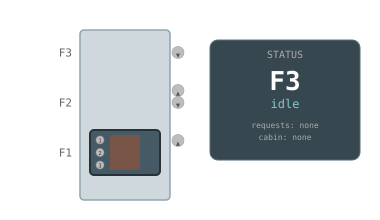

In [5]:
with open("./elevator/Elevator.svg") as f:
    elevator_svg = f.read()

FLOOR_Y = {"F1": 0, "F2": -50, "F3": -100}
BTN_ON, BTN_OFF = "#ffca28", "#bdbdbd"

# the same kind of {"selector.prop": fn} already written as
# widget[key] = (fn, method) bindings in Elevator.ipynb, minus the method
elevator_recipe = {
    "cabin-group.transform": lambda s: ("translate", (0, FLOOR_Y[s["floor"]])),
    "floor-display.text": lambda s: s["floor"],
    "btn-b1u.fill": lambda s: BTN_ON if s["b1u"] else BTN_OFF,
    "btn-c3.fill": lambda s: BTN_ON if s["c3"] else BTN_OFF,
}

elevator_states = [
    {"floor": "F1", "b1u": False, "c3": False},
    {"floor": "F1", "b1u": True,  "c3": False},  # press call button
    {"floor": "F1", "b1u": True,  "c3": True},   # press cabin button for F3
    {"floor": "F3", "b1u": False, "c3": False},  # arrival: cabin moves, buttons clear
]

elevator_anim = animate_trace(elevator_states, elevator_recipe, elevator_svg)
print(f"{len(elevator_anim.children)}-step scenario:")
for i, step in enumerate(elevator_anim.children):
    print(f"  step {i}: touches {sorted(step.touched_ids)}")

assert elevator_anim.children[0].touched_ids == {"btn-b1u"}
assert elevator_anim.children[1].touched_ids == {"btn-c3"}
assert elevator_anim.children[2].touched_ids == {"cabin-group", "floor-display", "btn-b1u", "btn-c3"}

first_frame = svg_generator(elevator_states[0], elevator_recipe, elevator_svg)
IPython.display.SVG(compile_to_svg(elevator_anim, first_frame, leaf_dur=0.8))



### TODO:

- Wiring `svg_diff` into `FormalVizWidget`'s live JS runtime, so
  `w.transition(next_state)` derives `_bindings_meta`/`_binding_values`
  automatically instead of `Elevator.ipynb`/`Automotive.ipynb` hand-tagging
  `"tween"`/`"snap"` per property.
- `compile_to_svg` above is a minimal SMIL renderer for visual inspection
  only (fixed per-`Leaf` duration, simple `begin="id.end"` chaining), not
  the `values`/`keyTimes`-chained trace `FormalVizWidget._append_smil_trace`
  already produces for static export.
- `compile_to_svg`'s text ops (e.g. `floor-display`) bake their final
  value in immediately at compile time, ignoring `begin`. SMIL has no
  declarative way to defer a `textContent` write, so a static preview can
  show a label slightly ahead of where the rest of the animation is.
